# Reproducing the manuscript figures

Every figure in the paper, regenerated from this repository's pipeline code with no manual
editing and no image post-processing. Each section states which figure it produces, what the
figure shows, and writes it to `paper_figures/img/` under the exact filename the manuscript
expects.

## What this notebook needs

| Input | Where it comes from |
|---|---|
| Derived observables per planet | `01_observables.ipynb` (pipeline step 1) |
| Independent stellar-density samples | `pipeline/<case>/inputs/rho_true_data/` |
| Posterior chains for the adopted runs | `pipeline/<case>/results/exorings/` |
| Published reference values | `photoring.literature` |

The posterior chains for the manuscript's adopted configuration are **versioned in this
repository as reference artefacts**, so the figures reproduce immediately without re-running
the retrievals. `pipeline/<case>/results/` is otherwise gitignored: everything else there is
regenerable output. To reproduce those chains from scratch instead, see
[`../pipeline/README.md`](../pipeline/README.md) — the run tag encodes the full configuration.

## Style

`plot.apply_style(plot.PAPER_STYLE)` switches the shared plotting layer to the manuscript's
appearance: saturated per-planet colours, real LaTeX rendering, and dynesty's default 95%
credible interval in the corner titles. Every figure below is drawn through that one style
authority, so they are consistent with each other by construction rather than by hand.

`PAPER_STYLE` sets `use_latex=True`, which needs a working TeX installation. Without one, set
`plot.apply_style(plot.PAPER_STYLE | {"use_latex": False})` — the figures still render, with
mathtext instead of TeX.


## 0. Environment

In [1]:
# ── Bootstrap: make the repository packages importable without installation ──
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline").is_dir() and (c / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO), str(_REPO / "pipeline")):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)

repo root: /home/numpaque/AppPR


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
import photoring.plotting as plot
from photoring import literature, contour
from photoring.io import load_observables, load_run

# The manuscript's look: saturated palette, LaTeX, 95% corner intervals.
plot.apply_style(plot.PAPER_STYLE)

CASE = "kepler_51"
# This notebook does not live in pipeline/, so point CasePaths at it explicitly.
paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
IMG = pathlib.Path(_REPO / "paper_figures" / "img")
# Posterior chains behind the manuscript figures, versioned as reference artefacts.
REFERENCE_RUNS = pathlib.Path(_REPO / "paper_figures" / "reference_runs")
IMG.mkdir(parents=True, exist_ok=True)
print("writing figures to:", IMG)

writing figures to: /home/numpaque/AppPR/paper_figures/img


In [3]:
%load_ext autoreload
%autoreload 2

## 1. Configuration — the adopted runs

The manuscript's ring-geometry figures use the **fully free** model
($f_e,\ i_R,\ \theta,\ p,\ \tau,\ \rho_{\star,\rm true},\ b$ all sampled) with the likelihood
$\mathcal{L}_{\rm KDE} = (\delta,\ T_{14},\ \rho_{\star,\rm obs})$, nested sampling at
$N_{\rm live}=1200$ and $\Delta\ln Z = 0.01$, and $N_{\rm KDE}=5000$ training samples.

That combination was adopted because it is the only one in the retrieval suite that
reproduces the **full** set of transit observables — including the ones left out of the
likelihood. Simpler configurations fit their own likelihood observables but mispredict the
durations.


In [4]:
RUN_SUFFIX = ("NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01"
              "_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE")
PLANETS = ["b", "d"]

runs = {}
for pl in PLANETS:
    npz = REFERENCE_RUNS / f"{CASE}_{pl}_{RUN_SUFFIX}.npz"
    if not npz.exists():
        print(f"MISSING: {npz.name}")
        continue
    runs[pl] = load_run(npz)
    r = runs[pl]
    print(f"planet {pl}: ndim={len(r['param_names'])}  lnZ={r['logz']:.3f}  "
          f"L_KDE={r['kde_obs']}  n={len(r['chain'])}")

ttv = {pl: load_observables(paths.observables_file(pl)) for pl in PLANETS}
rho_true_samples = np.loadtxt(paths.rho_true_samples) / 1000.0   # kg/m^3 -> g/cm^3
print("\nTTV observables loaded:", {k: len(v["delta"]) for k, v in ttv.items()})

planet b: ndim=7  lnZ=2.130  L_KDE=['delta', 'T14', 'rho_obs']  n=16694
planet d: ndim=7  lnZ=1.432  L_KDE=['delta', 'T14', 'rho_obs']  n=16006

TTV observables loaded: {'b': 17756, 'd': 39002}


## 2. The Photo-Ring effect across ring orientations

**Manuscript figure:** the PR heat map, `aPRe-PhotoRingContour-K51b.png`.

Shows $PR \equiv 10\log_{10}(\rho_{\star,\rm obs}/\rho_{\star,\rm true})$ over the plane of
effective ring orientation $(\cos i_{\rm R},\ \theta_{\rm R})$, for a Kepler-51 b analogue: a
compact planet of $1.9\,R_\oplus$ — the small, dense body the ring hypothesis implies rather
than the inflated radius a ringless fit returns — with $f_i = 1.0$, $f_e = 2.0$.

Two features carry the argument:

- the **thick black contour at $PR = 0$** is the density-degeneracy locus, where a ringed
  planet mimics a ringless one exactly: depth and durations are biased in compensating
  directions and the inferred density comes out right anyway. A null asterodensity result
  therefore does not exclude rings;
- **most of the plane has $PR < 0$**. Only a comparatively small region gives
  $\rho_{\star,\rm obs} > \rho_{\star,\rm true}$. The dashed red contour marks the *positive*
  anomaly actually measured for Kepler-51 b, so it delimits the orientations that could
  produce it — which is why the observed sign is informative about the geometry.

The map is computed with the independent, numerically-integrated `geotrans` model rather than
the pipeline's closed-form `exorings` model: this is a one-off grid, so accuracy matters more
than speed.


In [6]:
# Grid resolution of the published figure. Reduce for a quick look (it is ~6k
# numerical contact-time solutions at full resolution).
N_COS_IR, N_THETA = 81, 73

system = contour.default_system(Rp_earth=1.9, Rstar_sun=0.87, rho_star=1.896,
                                P_days=45.155, b=0.0, fi=1.0, fe=2.0, tau=1.0)
print(f"p = Rp/R* = {system.p:.5f}   a/R* = {system.aRs:.2f}")

COS_IR, THETA, PR, DELTA_RING = contour.compute_pr_map(
    system, n_cos_ir=N_COS_IR, n_theta=N_THETA)
print(f"PR range: {PR.min():.2f} .. {PR.max():.2f}")

p = Rp/R* = 0.01998   a/R* = 58.90
PR range: -4.47 .. 1.99


  Saved -> /home/numpaque/AppPR/paper_figures/img/aPRe-PhotoRingContour-K51b.png


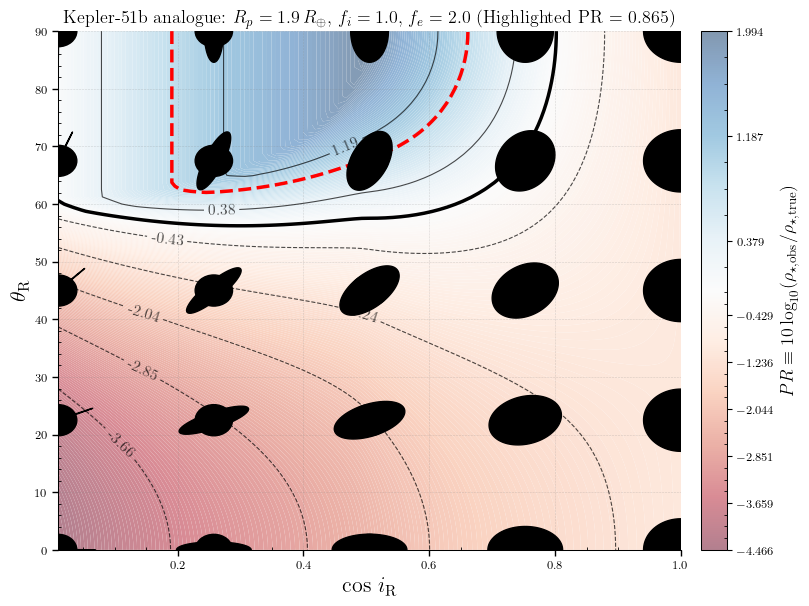

In [8]:
# The measured anomaly for planet b, PR = 0.87 +/- 0.12 against a 2 g/cm^3 reference.
PR_OBSERVED_B = 0.865

fig = contour.plot_pr_contour(
    COS_IR, THETA, PR, system,
    highlight=PR_OBSERVED_B, draw_zero=True,
    title=(r"Kepler-51b analogue: $R_p = 1.9\,R_\oplus$, $f_i = 1.0$, $f_e = 2.0$ "
           rf"(Highlighted PR = {PR_OBSERVED_B})"),
    out_path=IMG / "aPRe-PhotoRingContour-K51b.png",
)
plt.show()

## 3. Transit observable posteriors

**Manuscript figure:** `k51_observables_posteriors.png`.

One row per planet, one column per observable. Filled distributions are this work's TTV
posteriors; vertical dashed lines and the accompanying labels give the median and 68%
credible interval. Unfilled curves are literature estimates built from published point values
and their reported uncertainties — a truncated normal for the impact parameter, whose physical
range is bounded. Only the observables a given source reports are drawn, which is why some
columns (notably $T_{23}$) carry no overlay.

Where the literature scatter exceeds the individual error bars, that is itself a result: for
the transit depth it points to unocculted stellar activity — Kepler-51 is young ($\sim$500 Myr)
and magnetically active, so an evolving spot distribution changes the out-of-transit flux and
inflates the measured depth if unmodelled. The impact parameter is the least constrained
observable, because Kepler's $\sim$30-minute cadence smears exactly the ingress/egress slopes
that carry the chord geometry. By contrast $a/R_\star$ is the most consistently determined,
being set almost entirely by the precisely measured period and total duration.


-> /home/numpaque/AppPR/paper_figures/img/k51_observables_posteriors.png


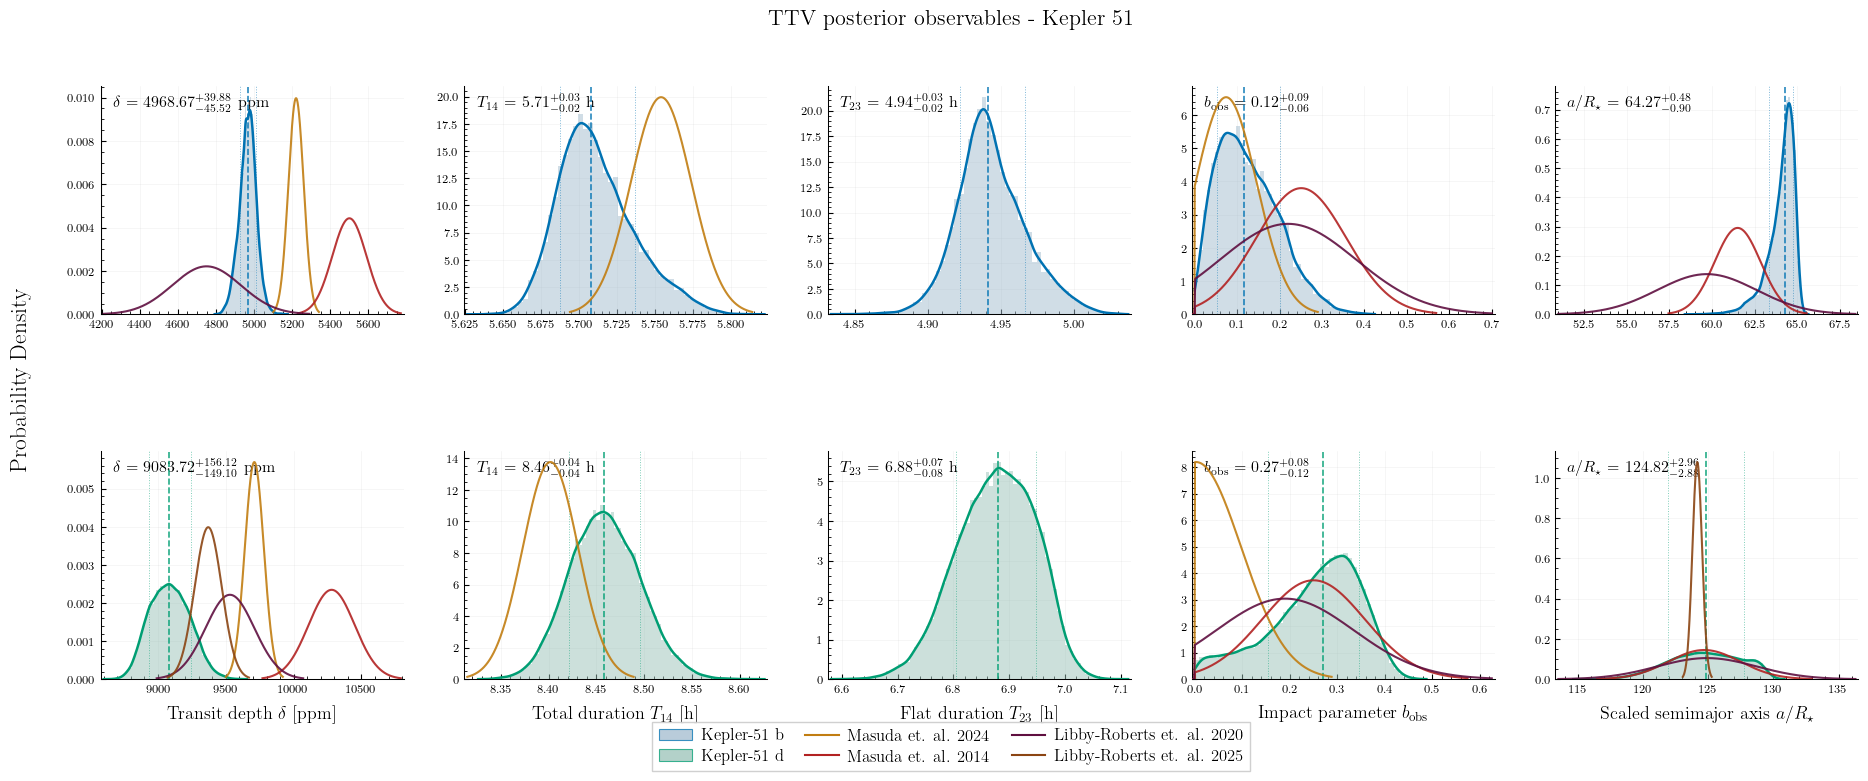

In [9]:
fig = plot.plot_observable_posteriors(
    ttv,
    keys=["delta", "T14", "T23", "b_obs", "aR"],
    lit=literature.observables(CASE),
    title=f"TTV posterior observables - {CASE.replace('_', ' ').title()}",
)
fig.savefig(IMG / "k51_observables_posteriors.png", dpi=plot.STYLE["fig_dpi"],
            bbox_inches="tight")
print("->", IMG / "k51_observables_posteriors.png")
plt.show()

## 4. The stellar-density anomaly

**Manuscript figure:** `rho_obs_comparison.png`.

The pivotal measurement. Under the standard transit model — unblended, spot-free light curves,
spherical planets on circular orbits — *every* transiting planet of a system must yield the
same $\rho_{\star,\rm obs}$. So any disagreement between planets, or against an independent
determination of the star's density, means the standard model is failing to capture something
about the real transit geometry for at least one planet.

Filled distributions are the transit-derived densities for b and d; the filled reference
distribution is the isochrone-based posterior for the *true* stellar density; dotted curves
are independent literature determinations, drawn as two-sided Gaussians because they are
reported with asymmetric uncertainties.

Three explanations are possible: unmodelled starspots biasing $(a/R_\star)_{\rm obs}$, an
incomplete picture of the system's dynamics, or a ring system. The rest of the pipeline tests
the third — not as the preferred explanation, but to establish whether a ringed geometry can
reconcile the transit observables with a self-consistent stellar density.

Note the **sign**: the anomaly here is positive ($\rho_{\star,\rm obs} > \rho_{\star,\rm true}$),
the less common of the two PR regimes (§2). That does not disfavour rings — physically valid
solutions span both — but it does confine them to a restricted part of orientation space.


-> /home/numpaque/AppPR/paper_figures/img/rho_obs_comparison.png


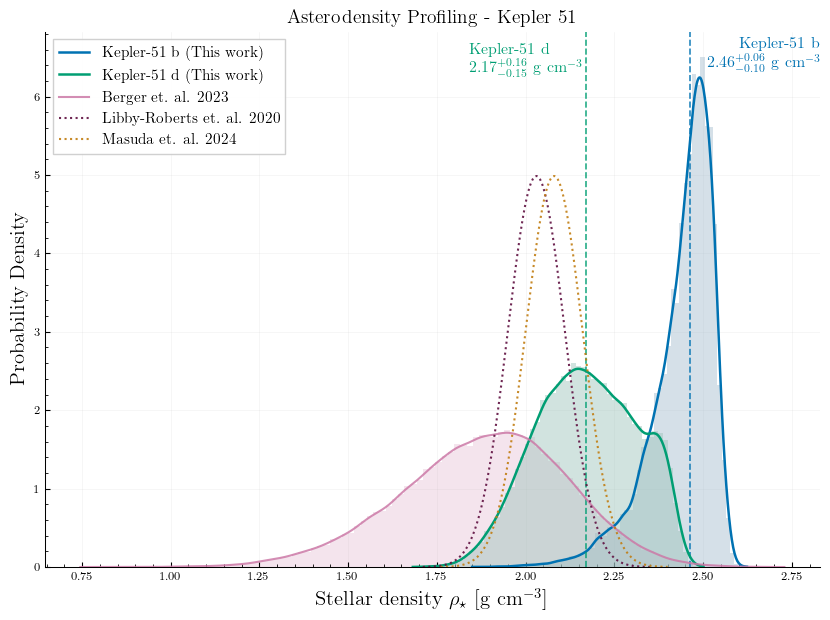

In [10]:
fig = plot.plot_asterodensity_profiling(
    ttv,
    rho_true_samples=rho_true_samples,
    # The independent (non-transit) determination the anomaly is measured against.
    rho_true_label="Berger et. al. 2023",
    lit_rho=literature.rho_star(CASE),
    title="Asterodensity Profiling - Kepler 51",
    # Place each planet's label near its own median, clear of the legend and of each other.
    # (x_in_data, ypos, offset, xpos) per planet — keeps each label by its own median,
    # clear of the legend and of the other planet's label.
    annot_offsets={"b": (float(np.median(ttv["b"]["rho_obs_gcc"])) + 0.2, 0.98, 0.01, "right"),
                   "d": (float(np.median(ttv["d"]["rho_obs_gcc"])) + 0.03, 0.98, 0.0, "left")},
)
fig.savefig(IMG / "rho_obs_comparison.png", dpi=plot.STYLE["fig_dpi"], bbox_inches="tight")
print("->", IMG / "rho_obs_comparison.png")
plt.show()

## 5. Segment consistency

**Manuscript figure:** `k51_observables_posteriors_segments.png` (the segment-consistency
check for Kepler-51 b).

Kepler-51 b's light curve had to be split into three independent temporal segments: with a
free mid-transit time per epoch, a single nested-sampling run over all epochs is
computationally intractable. Each segment was fitted separately and the three posteriors
combined by importance sampling (their product — see
[`../pipeline/01_observables.ipynb`](../pipeline/01_observables.ipynb) §2).

This figure is the diagnostic that the combination is defensible. Filled areas are normalised
histograms per segment, solid curves their KDEs, and the vertical dashed line the median of
the combined posterior.

$p$, $\delta$ and $a/R_\star$ agree well across segments; $T_{14}$, $T_{23}$ and
$\rho_{\star,\rm obs}$ visibly do not. That is expected rather than alarming: Kepler-51 b
shows large-amplitude TTVs, so distinct stretches of the light curve sample different stages
of the system's dynamical evolution and shift the inferred transit-shape parameters
segment by segment.


-> /home/numpaque/AppPR/paper_figures/img/k51_observables_posteriors_segments.png


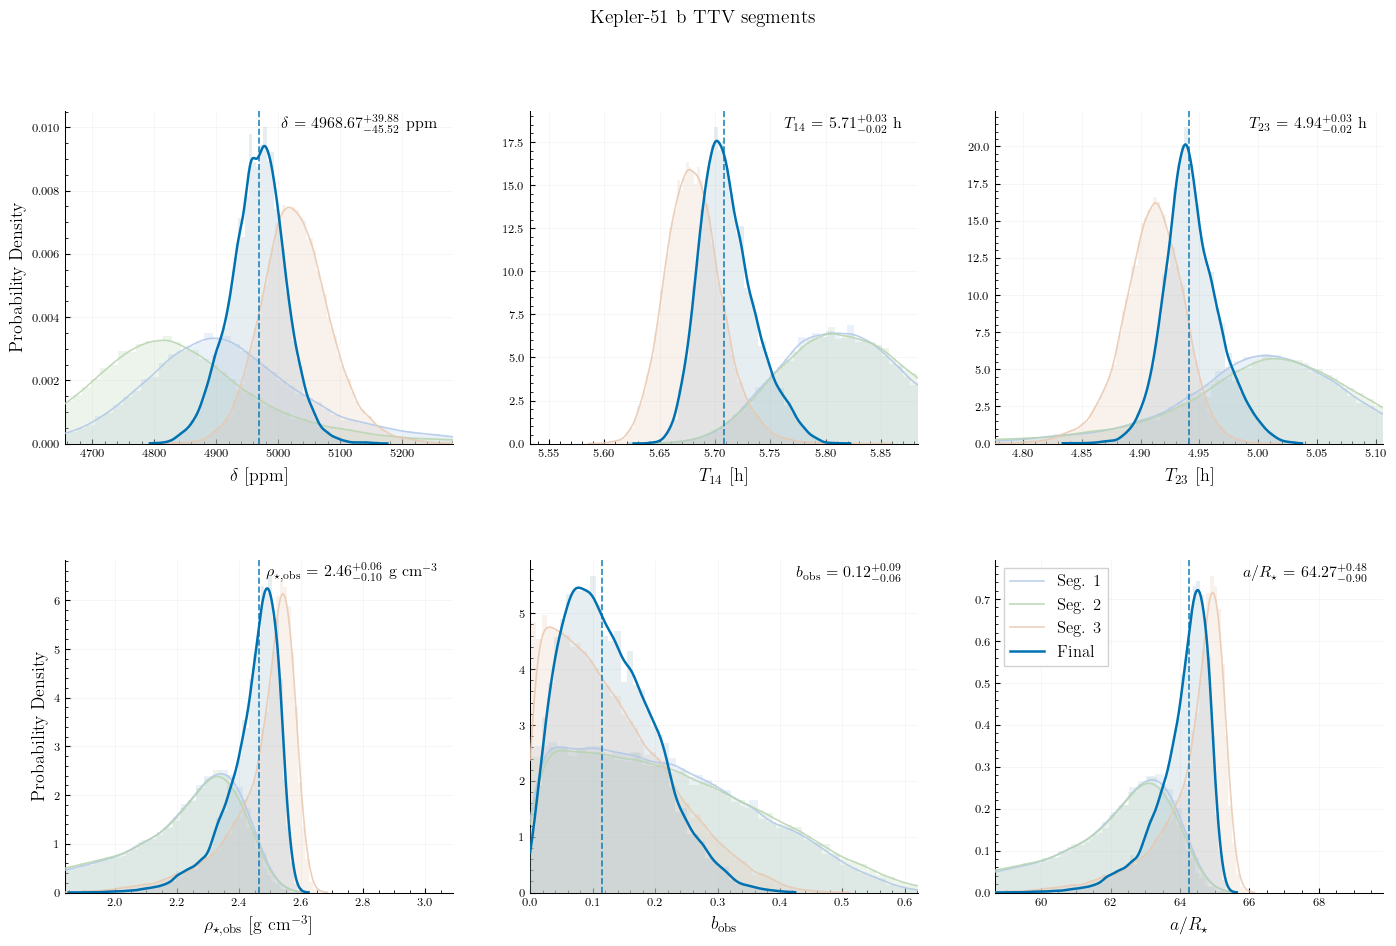

In [11]:
from photoring.observables import load_posterior, derive_observables

COLS = dict(col_p=0, col_rho=1, col_b=2, col_per=3, col_tmid=4, col_logl=-1)
SEG_FILES = ["Kepler-51b/TTVplan1-post_equal_weights.dat",
             "Kepler-51b/TTVplan2-post_equal_weights.dat",
             "Kepler-51b/TTVplan3-post_equal_weights.dat"]

segs = [derive_observables(load_posterior(paths.ttv_dir / f, **COLS)) for f in SEG_FILES]

# The combined posterior is what step 1 already wrote out; reload it rather than
# recomputing the (expensive) importance-sampling combination here.
import pandas as pd
_c = np.loadtxt(paths.observables_file("b"))
combined = pd.DataFrame(_c, columns=["p", "delta", "aR", "rho_obs", "P",
                                     "b", "i_orb", "T14", "T23"])

fig = plot.plot_segment_consistency(
    segs, combined,
    keys=["delta", "T14", "T23", "rho_obs", "b_obs", "aR"],
    title="Kepler-51 b TTV segments",
)
fig.savefig(IMG / "k51_observables_posteriors_segments.png",
            dpi=plot.STYLE["fig_dpi"], bbox_inches="tight")
print("->", IMG / "k51_observables_posteriors_segments.png")
plt.show()

## 6. Inferred ring geometries

**Manuscript figures:** `final_planetb_panel_.png`, `final_planetd_panel_.png`.

Per planet: the joint posterior over ring and nuisance parameters, with a sky-plane sketch of
the inferred ring system at the posterior medians inset in the corner plot's free upper-right
triangle. The black disk is the planet, the elliptical annulus the ring.

The corner is drawn by `dynesty` from the **weighted** nested-sampling output, and the titles
report its default 95% credible interval. What to read off it:

- **$f_e$** lands well inside its uniform prior at both edges — a genuine constraint, not a
  prior artefact — and far below the prograde stability bound near $0.5\,R_{\rm Hill}$. The
  values are comparable to Saturn's main rings, which reach $\approx 2.3\,R_{\rm Saturn}$.
- **The $f_e$–$p$ anti-correlation** is the most persistent feature of the whole retrieval
  suite. The effective occulting area is $A_{\rm eff} = \pi R_p^2 + A_{\rm ring}$, so any
  $(p, f_e)$ pair preserving $A_{\rm eff}$ gives an identical transit depth and the sampler
  explores that iso-depth surface freely.
- **$i_R$ and $\theta$** favour moderately inclined rings. Because the prior on $i_R$ is
  already $\propto \sin i_R$ (isotropic, hence edge-on-favouring), any departure *from the
  prior shape* measures the information the data actually contributed.
- **$b$ and $\rho_{\star,\rm true}$** are nuisance parameters, sampled here rather than fixed.
  Their posteriors sit in tension with the external constraints, which is why the manuscript
  reports these as model-conditional geometric solutions rather than as a revision of the
  system's orbital architecture or the star's properties.


-> /home/numpaque/AppPR/paper_figures/img/final_planetb_panel_.png
-> /home/numpaque/AppPR/paper_figures/img/final_planetd_panel_.png


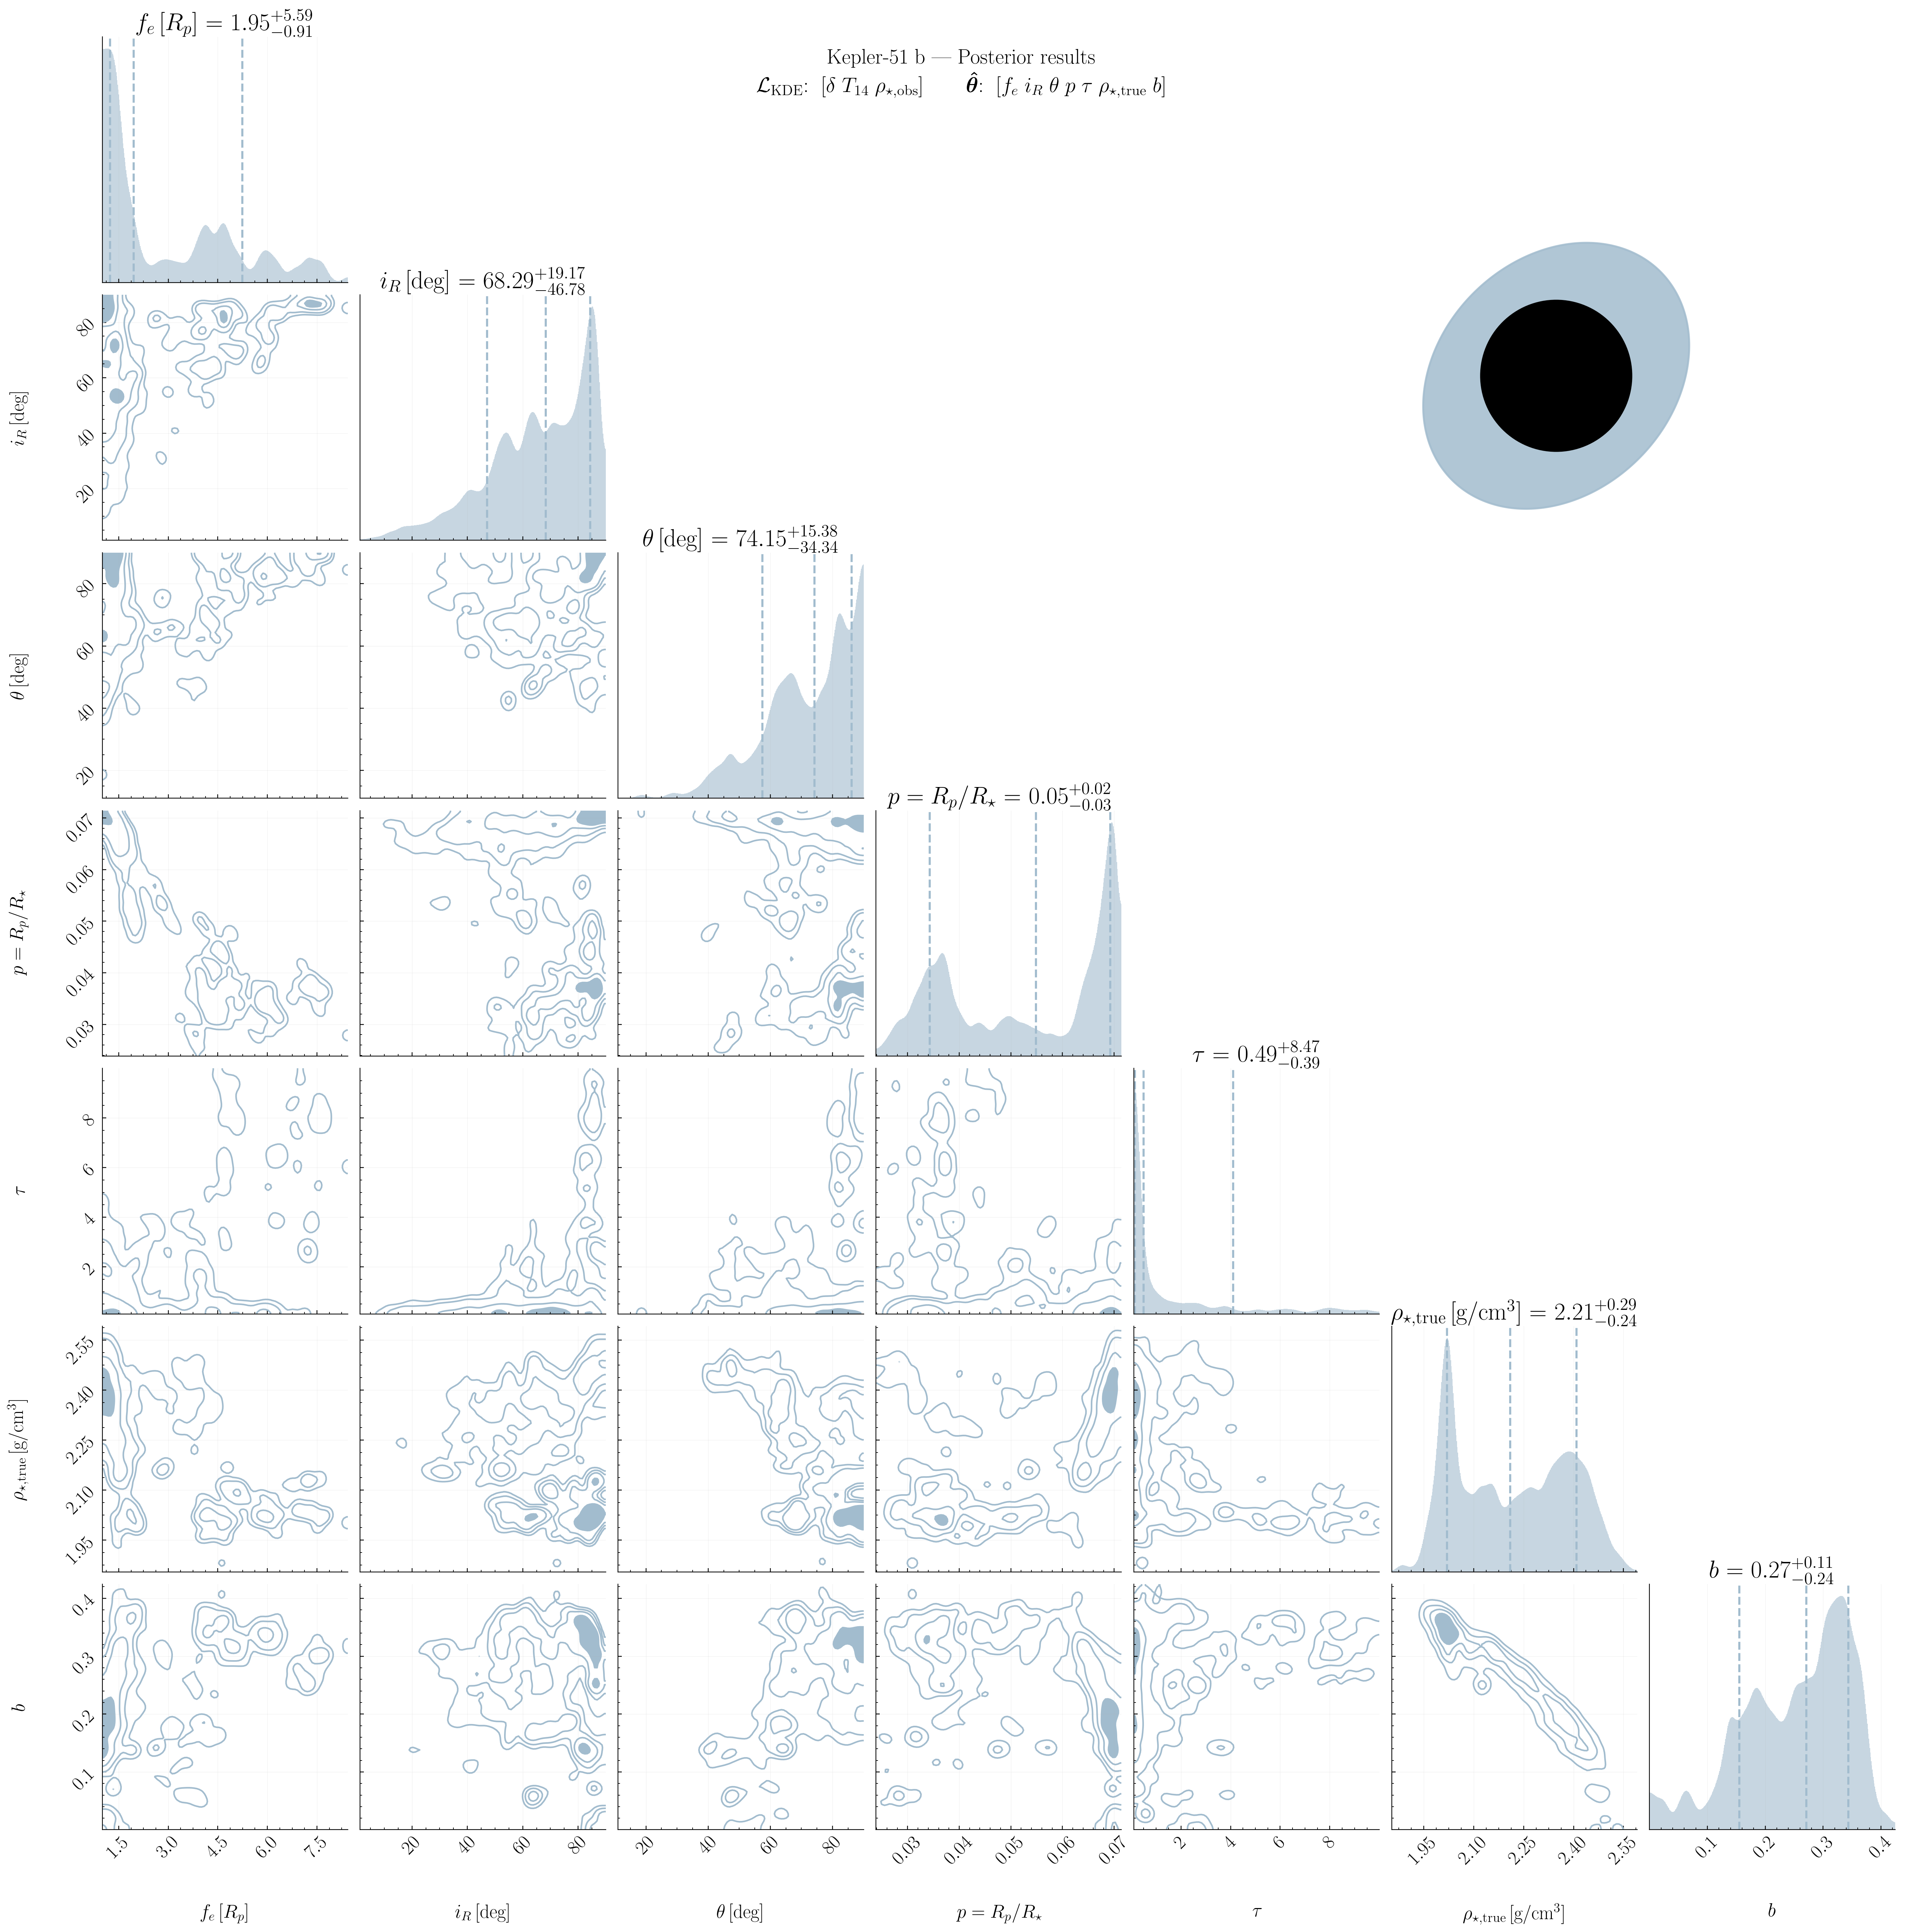

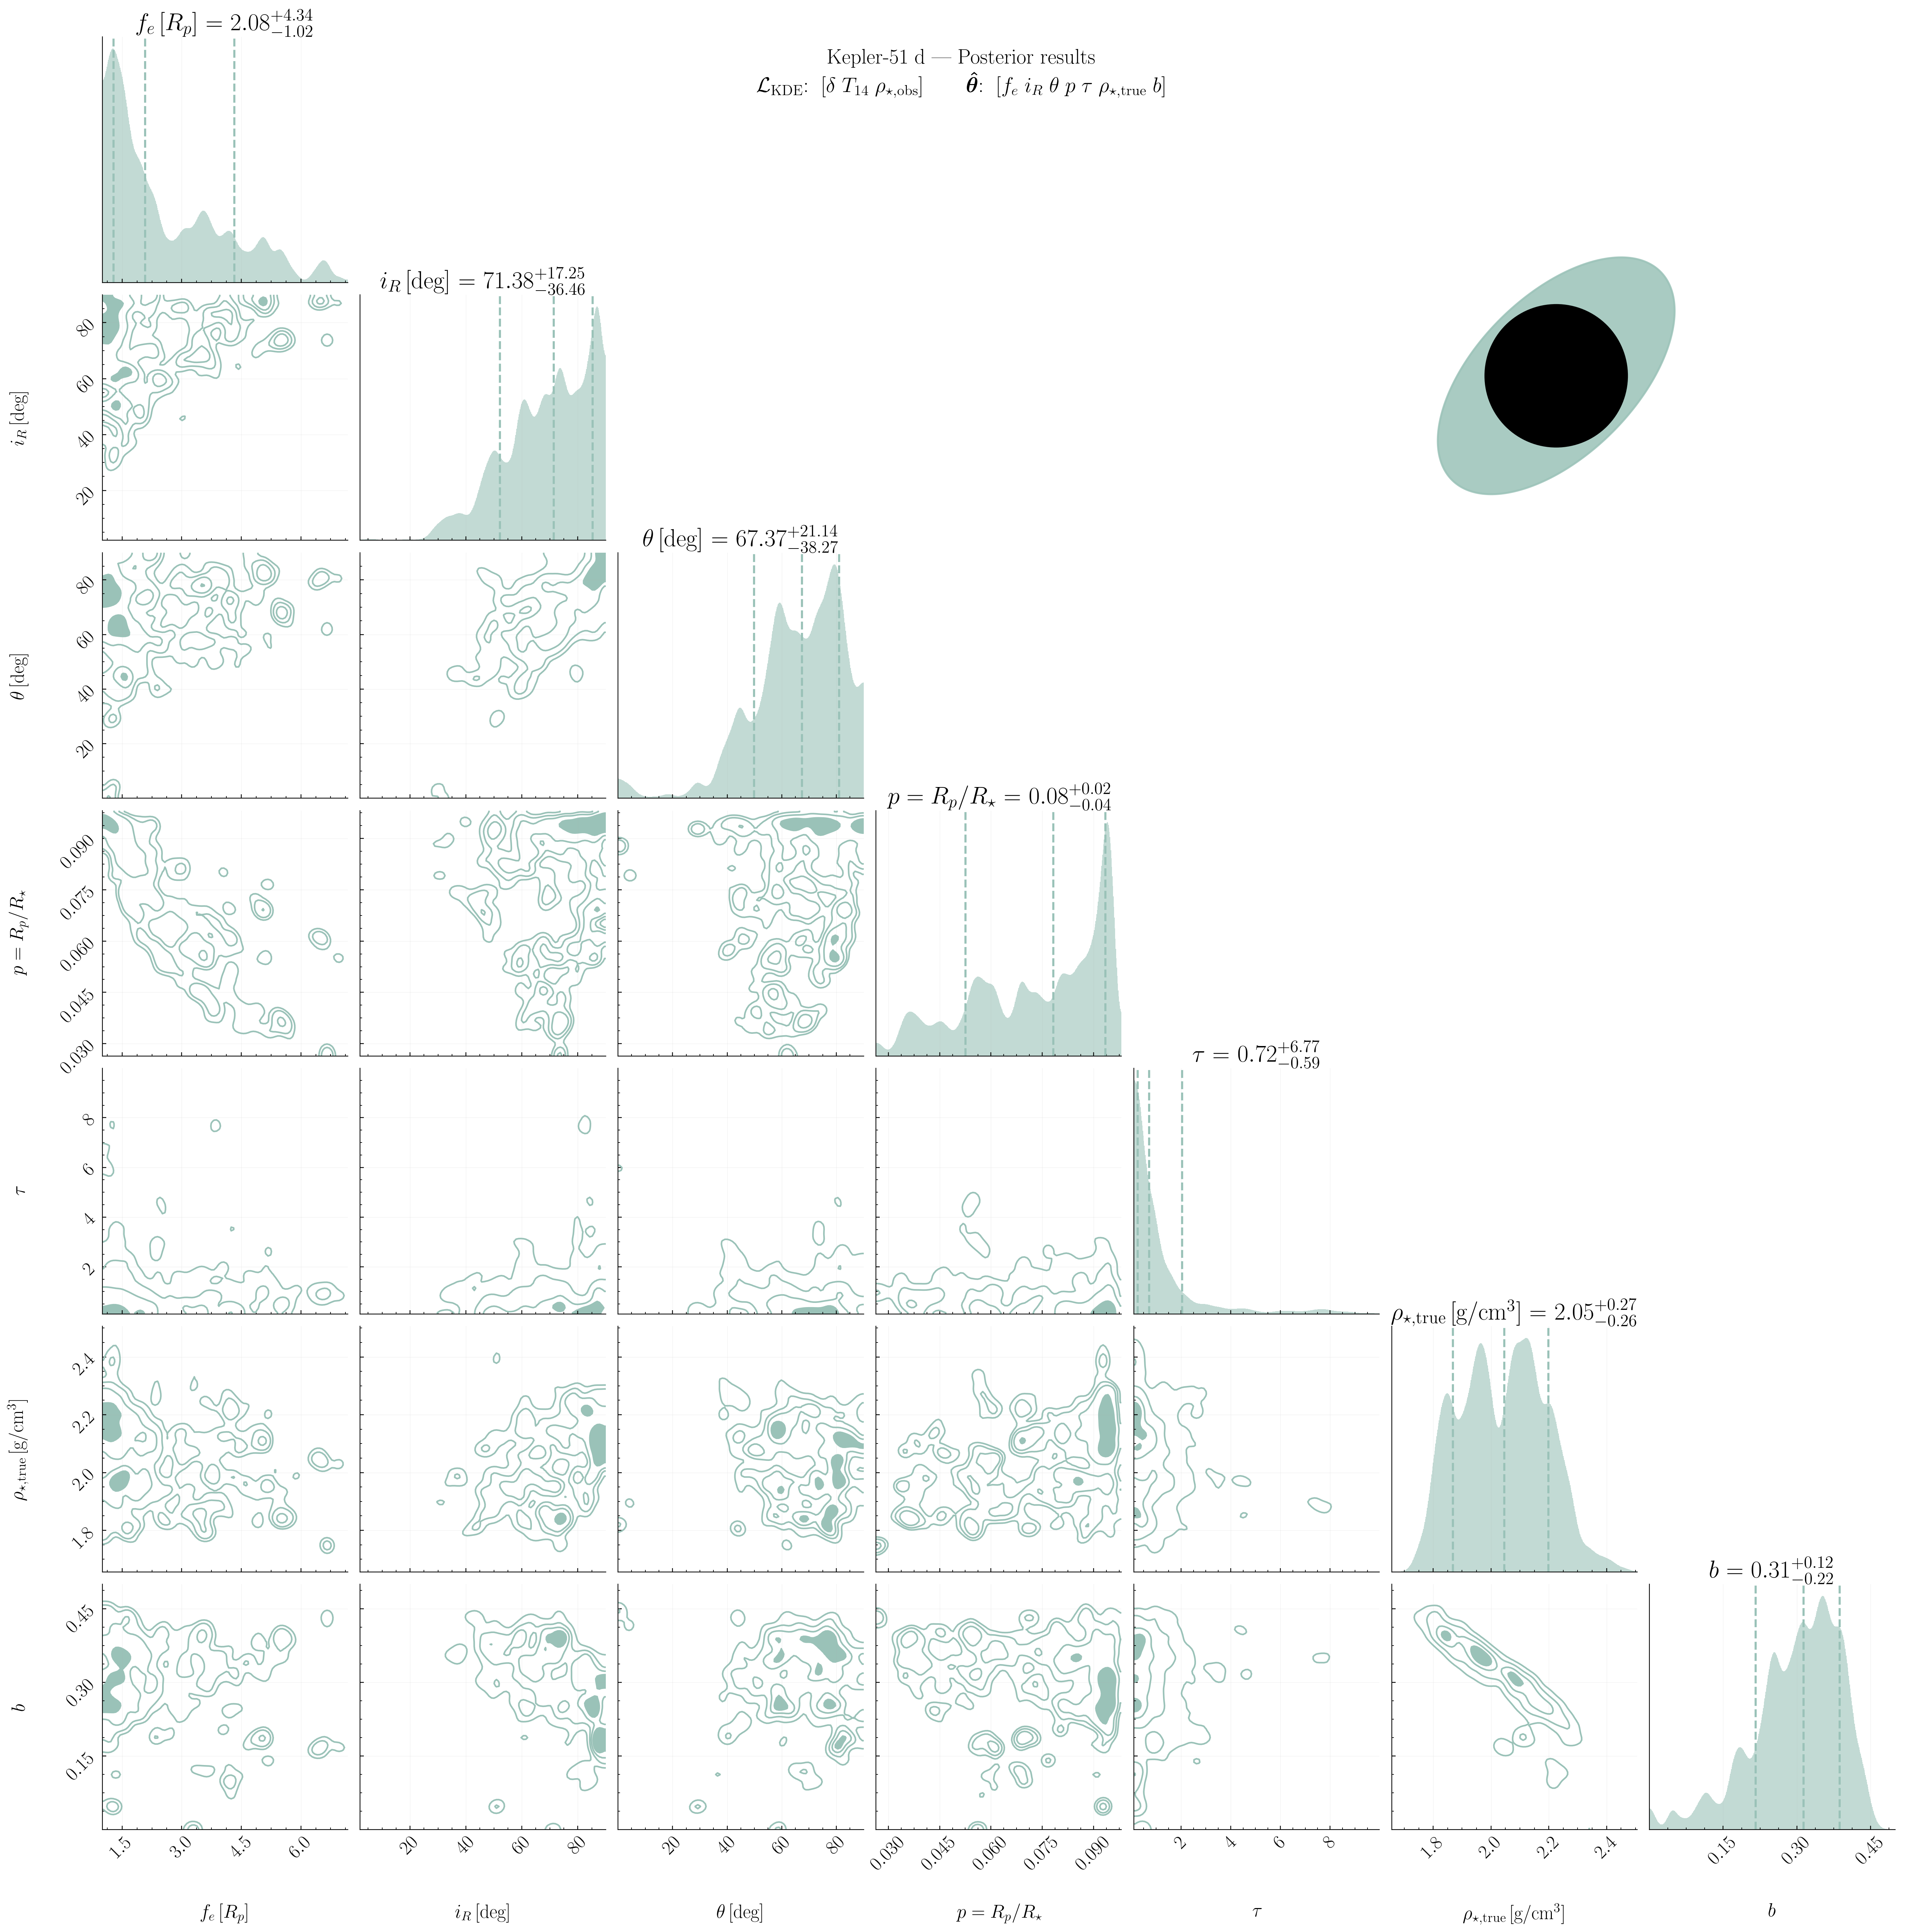

In [16]:
PANEL_NAME = {"b": "final_planetb_panel_.png", "d": "final_planetd_panel_.png"}

for pl, run in runs.items():
    fig = plot.plot_results_panel_inset(run)
    out = IMG / PANEL_NAME[pl]
    fig.savefig(out, dpi=plot.STYLE["fig_dpi"], bbox_inches="tight")
    print("->", out)
    # plt.close(fig)

## 7. Posterior predictive checks

**Manuscript figures:** `ppc_planet_b.png`, `ppp_planet_d.png`.

(The second filename's `ppp_` is a typo in the manuscript source; it is preserved here so the
paper still compiles.)

Posterior samples are pushed back through the forward model and the predicted distribution of
each observable is compared against the TTV-derived one. Three statistics quantify the match:

- $W_1$, the 1-Wasserstein distance — the mean absolute displacement between the two
  empirical distributions;
- $p_{\rm KS}$, the Kolmogorov–Smirnov $p$-value for the null hypothesis that both samples
  share a parent distribution;
- $E$, an energy distance — the squared discrepancy between the distributions.

**All five observables are checked, not just the ones in the likelihood.** Including an
observable in $\mathcal{L}_{\rm KDE}$ does not guarantee the rest are reproduced, so the
observables left out are an out-of-sample test of the inferred geometry. The panel titles mark
which is which. $b_{\rm obs}$ is always out-of-sample.


-> /home/numpaque/AppPR/paper_figures/img/ppc_planet_b.png
-> /home/numpaque/AppPR/paper_figures/img/ppp_planet_d.png


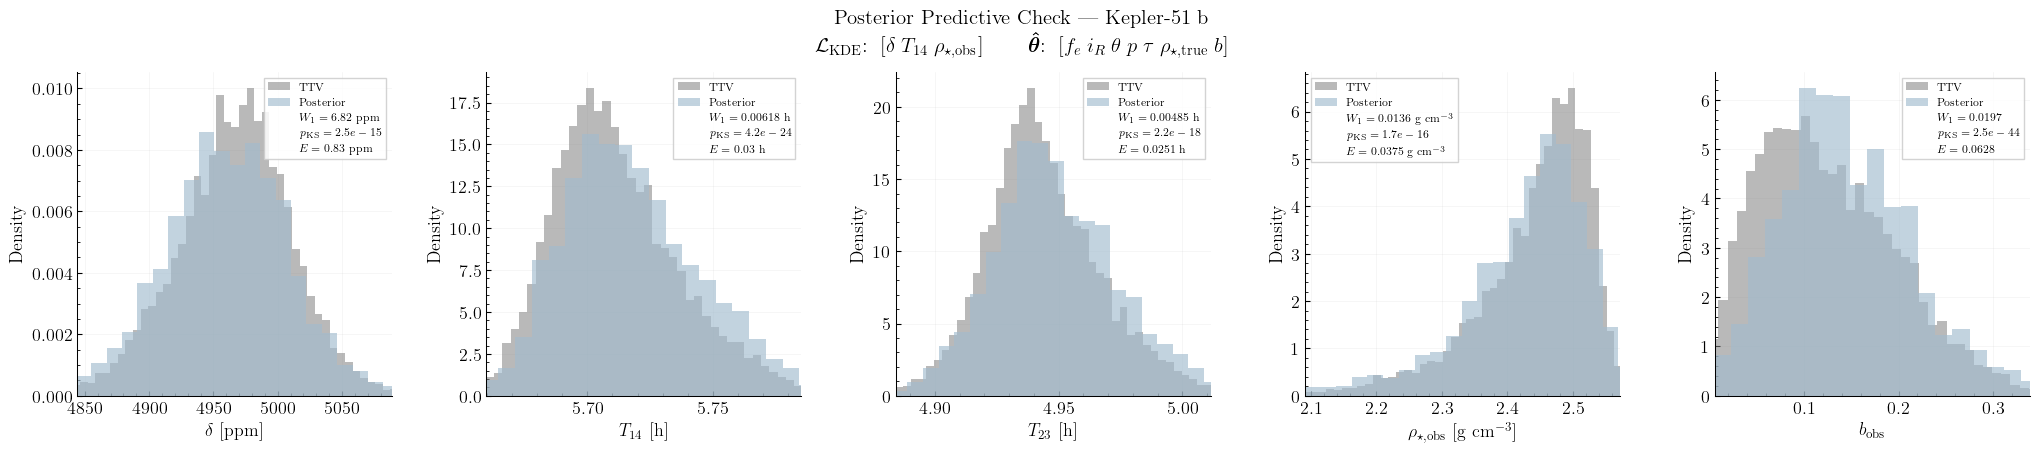

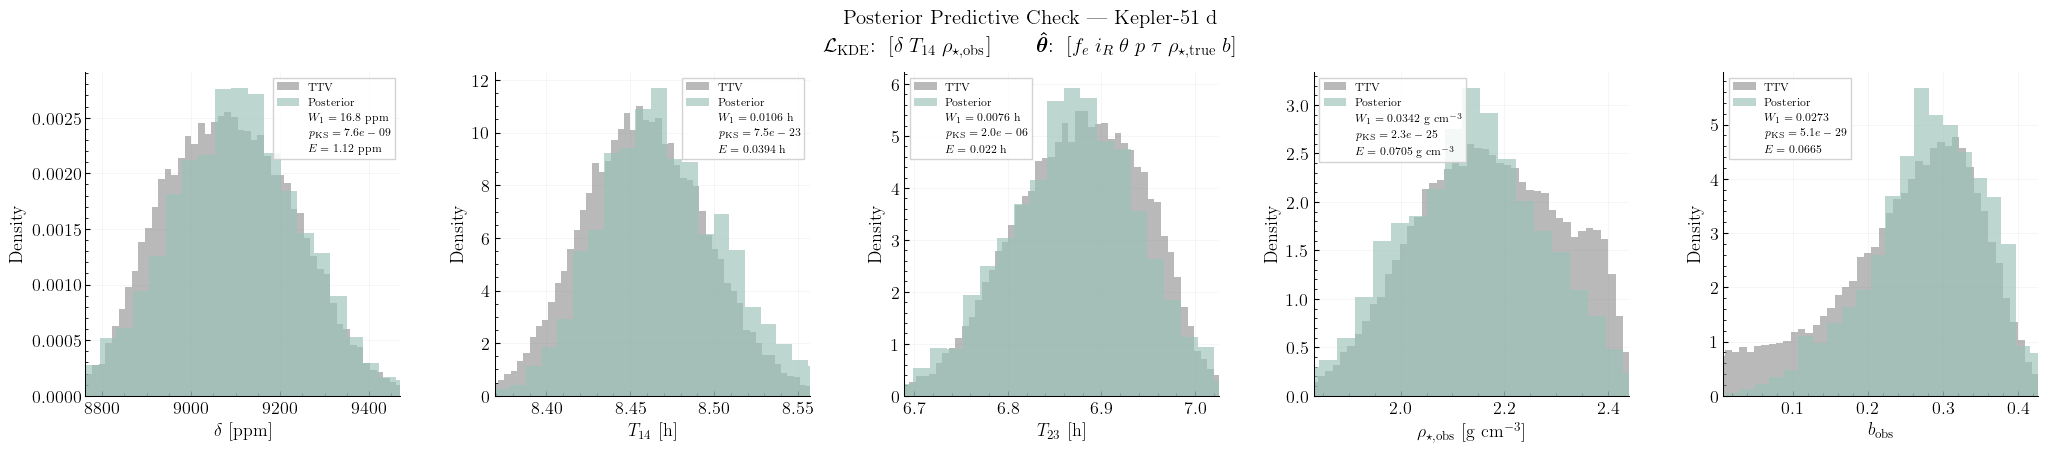

In [15]:
PPC_NAME = {"b": "ppc_planet_b.png", "d": "ppp_planet_d.png"}
PPC_OBSERVABLES = ["delta", "T14", "T23", "rho_obs", "b_obs"]

ppc_stats = {}
for pl, run in runs.items():
    fig, stats = plot.plot_ppc(run, ttv[pl], obs_keys=PPC_OBSERVABLES)
    ppc_stats[pl] = stats
    out = IMG / PPC_NAME[pl]
    fig.savefig(out, dpi=plot.STYLE["fig_dpi"], bbox_inches="tight")
    print("->", out)
    # plt.close(fig)

## 8. Tables

The manuscript's result tables, regenerated from the same chains. Paste the LaTeX bodies into
the corresponding `table*` environments.


In [14]:
print("=" * 70)
print("Posterior parameter summary (tab:ring_summary)")
print("=" * 70)
plot.print_summary_table(list(runs.values()), ppc_stats=None)

print()
print("=" * 70)
print("LaTeX bodies")
print("=" * 70)
plot.print_latex_table(list(runs.values()))

Posterior parameter summary (tab:ring_summary)
Run tag                                   param      median      -err      +err        ln Z
kepler_51_b_NS_exorings_kde_delta-T          fe     1.95061   0.71693   3.27249       2.130
kepler_51_b_NS_exorings_kde_delta-T          ir    68.46118  21.27393  15.88984            
kepler_51_b_NS_exorings_kde_delta-T       theta    74.10681  16.65848  12.02086            
kepler_51_b_NS_exorings_kde_delta-T           p     0.05485   0.02055   0.01444            
kepler_51_b_NS_exorings_kde_delta-T         tau     0.49698   0.35117   3.64330            
kepler_51_b_NS_exorings_kde_delta-T    rho_true     2.20956   0.19019   0.19971            
kepler_51_b_NS_exorings_kde_delta-T           b     0.27134   0.11659   0.07261            
------------------------------------------------------------------------------------------------------------
kepler_51_d_NS_exorings_kde_delta-T          fe     2.06968   0.78798   2.25348       1.432
kepler_51_d_NS_e

---

## Figure ↔ section map

| Manuscript figure | File | Section |
|---|---|---|
| PR heat map | `aPRe-PhotoRingContour-K51b.png` | §2 |
| Observable posteriors | `k51_observables_posteriors.png` | §3 |
| Stellar-density anomaly | `rho_obs_comparison.png` | §4 |
| Segment consistency | `k51_observables_posteriors_segments.png` | §5 |
| Ring geometry, planet b | `final_planetb_panel_.png` | §6 |
| Ring geometry, planet d | `final_planetd_panel_.png` | §6 |
| PPC, planet b | `ppc_planet_b.png` | §7 |
| PPC, planet d | `ppp_planet_d.png` | §7 |

Not generated here: `kepler_51b.png` (illustrative artwork) and `ringed_transit.pdf`
(a hand-drawn schematic). Both are inputs to the manuscript, not outputs of the analysis.
